# **News classification using GRUs**
SAARANG ARORA

Classification of news is something that we see prevalent in our daily lives. from newspapers having different pages for different types of news to modern browsers like Edge sorting news on its homepage. classification is sueful so that those who are reading the news can easily access the topic of their interest. be it entertainment news or economic. They need not go through the titles of each and every news article in order to gauge their interest in the topic, and th enews item itself.

Nowadays, due to the overwhelming amount of news, it is hard to manually classify these news articles, and a simple heurestical based keyword search is quite out of the picture due to the interconnectedness of the world nowadays. So, what is the solution? 

**AI**

Okay, that is a bit much but yes, it is AI, or atleast text classification techniques. Techniques such as TFIDF, BOW, and such are pretty decent at classification and basic sentiment analysis, but they often lose contextual clues, clues that are often important to the process of classification itself. so steps in what we are going to focus on today. **RNNs and LSTMs**

### What are GRUs?
**GRU**, or Gated Recurrent Unit is a type of recurrent neural network (RNN) that was introduced by Cho et al. in 2014 as a simpler alternative to Long Short-Term Memory (LSTM) networks. Like LSTM, GRU can process sequential data such as text, speech, and time-series data.

The basic idea behind GRU is to use gating mechanisms to selectively update the hidden state of the network at each time step. The gating mechanisms are used to control the flow of information in and out of the network. The GRU has two gating mechanisms, called the reset gate and the update gate.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/kaggle/input/labeled-newscatcher-dataaset/labeled_newscatcher_dataset.csv", delimiter=";")
df.head()

,topic,link,domain,published_date,title,lang
0,SCIENCE,https://www.eurekalert.org/pub_releases/2020-0...,eurekalert.org,2020-08-06 13:59:45,A closer look at water-splitting's solar fuel ...,en
1,SCIENCE,https://www.pulse.ng/news/world/an-irresistibl...,pulse.ng,2020-08-12 15:14:19,"An irresistible scent makes locusts swarm, stu...",en
2,SCIENCE,https://www.express.co.uk/news/science/1322607...,express.co.uk,2020-08-13 21:01:00,Artificial intelligence warning: AI will know ...,en
3,SCIENCE,https://www.ndtv.com/world-news/glaciers-could...,ndtv.com,2020-08-03 22:18:26,Glaciers Could Have Sculpted Mars Valleys: Study,en
4,SCIENCE,https://www.thesun.ie/tech/5742187/perseid-met...,thesun.ie,2020-08-12 19:54:36,Perseid meteor shower 2020: What time and how ...,en


## Data Exploration

In [3]:
df.describe()

,topic,link,domain,published_date,title,lang
count,108774,108774,108774,108774,108774,108774
unique,8,106130,5164,68743,103180,1
top,TECHNOLOGY,https://www.google.com/,dailymail.co.uk,2020-08-04 01:00:00,"US tops 5 million confirmed virus cases, to Eu...",en
freq,15000,19,1855,41,21,108774


from this, we can see at a glance that there is only one language, and that is english. So, we will drop that column. Additionally, the link will also not be very helpful to us in terms of classification of the topics; we will drop the link column as well. We will also drop the published date column.

I have kept the domain name as there are some domains that particularly deal with specific news, like EurekaAlert, which is a website that will have high cosine relation with SCIENCE topic.

In [4]:
df["topic"].unique()

array(['SCIENCE', 'TECHNOLOGY', 'HEALTH', 'WORLD', 'ENTERTAINMENT',
       'SPORTS', 'BUSINESS', 'NATION'], dtype=object)

In [5]:
df["domain"].unique()

array(['eurekalert.org', 'pulse.ng', 'express.co.uk', ...,
       'intothecalderon.com', 'the-daily-record.com',
       'ghanabusinessnews.com'], dtype=object)

In [6]:
df = df.drop(["link", "lang", "published_date"], axis=1)
# df = df.drop(df["lang"])
df

,topic,domain,title
0,SCIENCE,eurekalert.org,A closer look at water-splitting's solar fuel ...
1,SCIENCE,pulse.ng,"An irresistible scent makes locusts swarm, stu..."
2,SCIENCE,express.co.uk,Artificial intelligence warning: AI will know ...
3,SCIENCE,ndtv.com,Glaciers Could Have Sculpted Mars Valleys: Study
4,SCIENCE,thesun.ie,Perseid meteor shower 2020: What time and how ...
...,...,...,...
108769,NATION,vanguardngr.com,PDP governors’ forum urges security agencies t...
108770,BUSINESS,patentlyapple.com,"In Q2-20, Apple Dominated the Premium Smartpho..."
108771,HEALTH,belfastlive.co.uk,Coronavirus Northern Ireland: Full breakdown s...
108772,ENTERTAINMENT,thenews.com.pk,Paul McCartney details post-Beatles distress a...


Now, I will add the domain name to the end of the title so that we can get a single string out of the title and the domain name.

In [7]:
df["title_domain"] = df["title"] + " " + df["domain"]
df = df.drop(["title", "domain"], axis=1)

In [8]:
df["title_domain"][2]

'Artificial intelligence warning: AI will know us better than we know ourselves express.co.uk'

Now that we just have the textual data, we will need start with the pre-processing of the data in order to feed it into the models.

## Model Pre-Processing
for NLP, the typical pre-processing steps that we will follow are the following - 
1. Dropping special characters
2. Dropping Stop words
3. Tokenization
4. Lemmatization/Stemming (we will go with lemmatization for reasons later explained)


In [9]:
import nltk
from nltk.tokenize import SpaceTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

Defining a funtion that will be useful to perform the functions in a modularized fashion.

In [10]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize the text
    tokenize = SpaceTokenizer()
    tokens = tokenize.tokenize(text)
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # # Lemmatize the tokens
    # lemmatizer = WordNetLemmatizer()
    # tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back into a string
    preprocessed_text = ' '.join(tokens)
    
    return preprocessed_text

In [11]:
df['preprocessed_title_domain'] = df['title_domain'].apply(preprocess_text)

# Show a sample of original and preprocessed text
print("Sample of original and preprocessed text:")
sample_df = pd.DataFrame({
    'Original': df['title_domain'][:5],
    'Preprocessed': df['preprocessed_title_domain'][:5]
})
print(sample_df)

Sample of original and preprocessed text:
                                            Original  \
0  A closer look at water-splitting's solar fuel ...   
1  An irresistible scent makes locusts swarm, stu...   
2  Artificial intelligence warning: AI will know ...   
3  Glaciers Could Have Sculpted Mars Valleys: Stu...   
4  Perseid meteor shower 2020: What time and how ...   

                                        Preprocessed  
0  closer look watersplittings solar fuel potenti...  
1  irresistible scent makes locusts swarm study f...  
2  artificial intelligence warning ai know us bet...  
3  glaciers could sculpted mars valleys study ndt...  
4  perseid meteor shower  time see huge bright fi...  


In [12]:
df

,topic,title_domain,preprocessed_title_domain
0,SCIENCE,A closer look at water-splitting's solar fuel ...,closer look watersplittings solar fuel potenti...
1,SCIENCE,"An irresistible scent makes locusts swarm, stu...",irresistible scent makes locusts swarm study f...
2,SCIENCE,Artificial intelligence warning: AI will know ...,artificial intelligence warning ai know us bet...
3,SCIENCE,Glaciers Could Have Sculpted Mars Valleys: Stu...,glaciers could sculpted mars valleys study ndt...
4,SCIENCE,Perseid meteor shower 2020: What time and how ...,perseid meteor shower time see huge bright fi...
...,...,...,...
108769,NATION,PDP governors’ forum urges security agencies t...,pdp governors forum urges security agencies re...
108770,BUSINESS,"In Q2-20, Apple Dominated the Premium Smartpho...",q apple dominated premium smartphone segment i...
108771,HEALTH,Coronavirus Northern Ireland: Full breakdown s...,coronavirus northern ireland full breakdown sh...
108772,ENTERTAINMENT,Paul McCartney details post-Beatles distress a...,paul mccartney details postbeatles distress bl...


In [13]:
from statistics import mean

def analyze_text_lengths(df, column_name):
    # Convert texts to list of tokens and calculate lengths
    text_lengths = df[column_name].apply(lambda x: len(x.split()))
    
    # Calculate statistics
    shortest_len = text_lengths.min()
    longest_len = text_lengths.max()
    avg_len = text_lengths.mean()
    
    # Get examples of shortest and longest texts
    shortest_text = df.loc[text_lengths.idxmin(), column_name]
    longest_text = df.loc[text_lengths.idxmax(), column_name]

    
    return {
        'shortest_length': shortest_len,
        'longest_length': longest_len,
        'average_length': avg_len,
        'shortest_text': shortest_text,
        'longest_text': longest_text,
        }

# Analyze the lengths
stats = analyze_text_lengths(df, 'preprocessed_title_domain')
stats

{'shortest_length': 2,
 'longest_length': 37,
 'average_length': 9.352896831963522,
 'shortest_text': 'expired thurrottcom',
 'longest_text': 'coronavirus australia live updates august   new covid cases  deaths victoria nz ready worst case scenario probe virus arrived freight trump says us economy strong calls us schools reopen epidemiologist says melbourne past peak  breaking news today newscomau'}

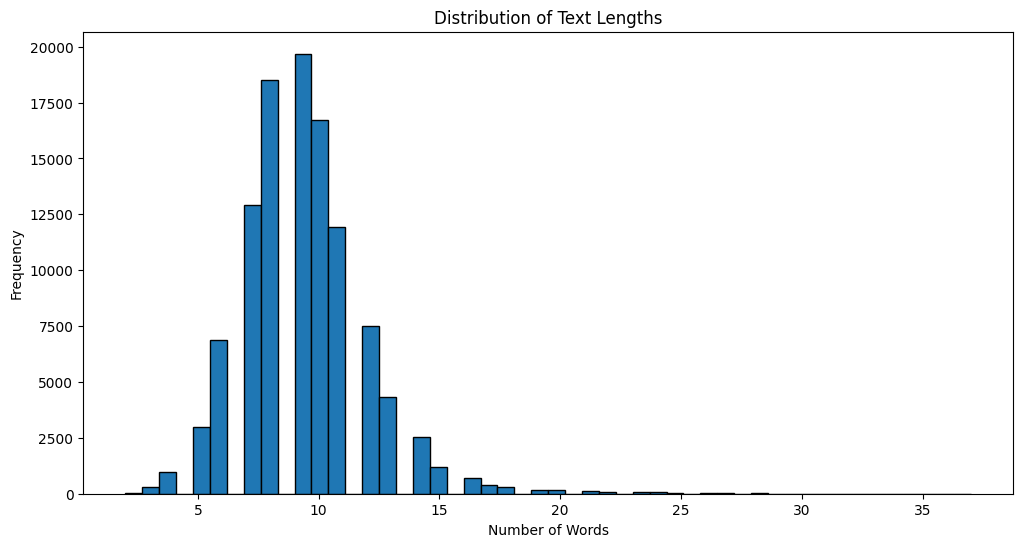


Recommended average length for padding: 9.352896831963522


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(df['preprocessed_title_domain'].apply(lambda x: len(x.split())), 
         bins=50, edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Save length statistics for later use in padding/truncating
max_length = stats['longest_length']
print(f"\nRecommended average length for padding: {stats['average_length']}")

as we can see, the average length of the texts is 9.35; taking a number around that will be appropriate. so I will select a input length of 12 so that accomodates some titles of higher number of words as well (as seen in the diagram.)

## Data Preperation

Now that we have pre-processed the data, we are going to prepare teh data so that it can be inputted into RNNs and LSTMs. for this, we have to make word embeddings, basically convert each word into a vector and then embed them in relation to each other in a vactor space.

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, LSTM, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

## text preprocessing modules
from gensim.parsing.preprocessing import remove_stopwords
from gensim.models import Word2Vec

### Word Embedding

In [16]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

def create_word_embeddings(df, text_column, label_column, max_length=12, vocab_size=65000):
    """
    Create word embeddings and encode labels for RNN processing.
    
    Args:
        df (pandas.DataFrame): Input dataframe
        text_column (str): Name of the column containing preprocessed text
        label_column (str): Name of the column containing labels
        max_length (int): Maximum length of sequences
        vocab_size (int): Maximum number of words to keep
    
    Returns:
        tuple: (padded_sequences, encoded_labels, tokenizer, label_encoder)
    """
    # Initialize the tokenizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token='UNK')
    
    # Fit the tokenizer on the texts
    tokenizer.fit_on_texts(df[text_column])
    
    # Convert texts to sequences
    sequences = tokenizer.texts_to_sequences(df[text_column])
    
    # Pad sequences to ensure uniform length
    padded_sequences = pad_sequences(sequences, 
                                   maxlen=max_length,
                                   padding='post',
                                   truncating='post')
    
    # Encode the labels
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(df[label_column])
    
    # Get vocabulary information
    word_index = tokenizer.word_index
    vocab_size = min(len(word_index) + 1, vocab_size)
    
    return {
        'padded_sequences': padded_sequences,
        'encoded_labels': encoded_labels,
        'tokenizer': tokenizer,
        'label_encoder': label_encoder,
        'vocab_size': vocab_size,
        'word_index': word_index
    }

# Create the embeddings
embedding_data = create_word_embeddings(
    df,
    text_column='preprocessed_title_domain',
    label_column='topic',
    max_length=12,
    vocab_size=65000
)

# Print some useful information about the embeddings
print("\nVocabulary Statistics:")
print(f"Total unique words: {len(embedding_data['word_index'])}")
print(f"Vocabulary size used: {embedding_data['vocab_size']}")

# Show shape of the padded sequences
print("\nSequence Information:")
print(f"Shape of padded sequences: {embedding_data['padded_sequences'].shape}")
print(f"Number of classes: {len(np.unique(embedding_data['encoded_labels']))}")

# Show a sample of the padded sequences
print("\nSample of padded sequences:")
print(embedding_data['padded_sequences'][:2])

# Show how some text got converted to sequences
sample_texts = df['preprocessed_title_domain'][:2]
print("\nExample of text to sequence conversion:")
for text in sample_texts:
    print(f"\nOriginal text: {text}")
    sequence = embedding_data['tokenizer'].texts_to_sequences([text])[0]
    padded = pad_sequences([sequence], maxlen=12, padding='post', truncating='post')
    print(f"Sequence: {sequence}")
    print(f"Padded sequence: {padded[0]}")

# Save the tokenizer and label encoder for later use
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(embedding_data['tokenizer'], f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(embedding_data['label_encoder'], f)


Vocabulary Statistics:
Total unique words: 64845
Vocabulary size used: 64846

Sequence Information:
Shape of padded sequences: (108774, 12)
Number of classes: 8

Sample of padded sequences:
[[ 1773   238 27921  1504  1015   372   337     0     0     0     0     0]
 [12658  7733   205  8330  8014    20   210  4108     0     0     0     0]]

Example of text to sequence conversion:

Original text: closer look watersplittings solar fuel potential eurekalertorg
Sequence: [1773, 238, 27921, 1504, 1015, 372, 337]
Padded sequence: [ 1773   238 27921  1504  1015   372   337     0     0     0     0     0]

Original text: irresistible scent makes locusts swarm study finds pulseng
Sequence: [12658, 7733, 205, 8330, 8014, 20, 210, 4108]
Padded sequence: [12658  7733   205  8330  8014    20   210  4108     0     0     0     0]


In [17]:
len(embedding_data['tokenizer'].word_index)

64845

In [18]:
embedding_data

{'padded_sequences': array([[ 1773,   238, 27921, ...,     0,     0,     0],
        [12658,  7733,   205, ...,     0,     0,     0],
        [ 2722,  2056,   282, ...,     0,     0,     0],
        ...,
        [    4,  1059,   318, ...,   819,   666,  5251],
        [  721,  7707,   443, ...,     0,     0,     0],
        [   17,   215,  4524, ...,     0,     0,     0]], dtype=int32),
 'encoded_labels': array([4, 4, 4, ..., 2, 1, 5]),
 'tokenizer': <keras.src.legacy.preprocessing.text.Tokenizer at 0x7bf078ef0e80>,
 'label_encoder': LabelEncoder(),
 'vocab_size': 64846,
 'word_index': {'UNK': 1,
  'covid': 2,
  'new': 3,
  'coronavirus': 4,
  'cases': 5,
  'says': 6,
  'us': 7,
  'market': 8,
  'news': 9,
  'first': 10,
  'global': 11,
  'vaccine': 12,
  'man': 13,
  'could': 14,
  'dailymailcouk': 15,
  'live': 16,
  'report': 17,
  'trump': 18,
  'may': 19,
  'study': 20,
  'virus': 21,
  'day': 22,
  'health': 23,
  'theguardiancom': 24,
  'death': 25,
  'expresscouk': 26,
  'one':

### Stratifying and splitting Train & Test data


Data Split Information:
Training set size: 87019 sequences
Test set size: 21755 sequences

Class Distribution Comparison:
               Overall   Train    Test
BUSINESS        0.1379  0.1379  0.1379
ENTERTAINMENT   0.1379  0.1379  0.1379
HEALTH          0.1379  0.1379  0.1379
NATION          0.1379  0.1379  0.1379
SCIENCE         0.0347  0.0347  0.0347
SPORTS          0.1379  0.1379  0.1379
TECHNOLOGY      0.1379  0.1379  0.1379
WORLD           0.1379  0.1379  0.1379


<Figure size 1200x600 with 0 Axes>

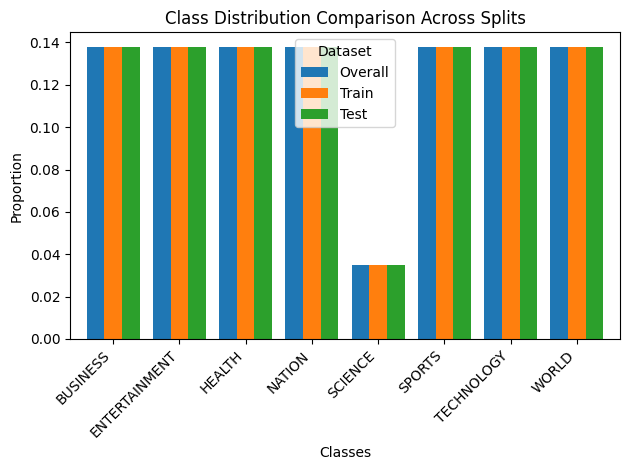


Verification Metrics:
Maximum distribution difference between train and test: 0.0000

Final Dataset Shapes:
X_train shape: (87019, 12)
X_test shape: (21755, 12)
y_train shape: (87019,)
y_test shape: (21755,)


In [19]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def create_stratified_split(X, y, test_size=0.2, random_state=42):
    """
    Create a stratified split of the data and verify class distributions.
    
    Args:
        X: Features (padded sequences)
        y: Labels (encoded)
        test_size: Proportion of test set
        random_state: Random seed for reproducibility
    
    Returns:
        tuple: (X_train, X_test, y_train, y_test, split_info)
    """
    # Perform stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    # Calculate class distributions
    train_dist = np.bincount(y_train) / len(y_train)
    test_dist = np.bincount(y_test) / len(y_test)
    overall_dist = np.bincount(y) / len(y)
    
    # Create distribution summary
    split_info = {
        'train_size': len(y_train),
        'test_size': len(y_test),
        'train_distribution': train_dist,
        'test_distribution': test_dist,
        'overall_distribution': overall_dist
    }
    
    return X_train, X_test, y_train, y_test, split_info

# Get the data from previous embedding step
X = embedding_data['padded_sequences']
y = embedding_data['encoded_labels']

# Create the stratified split
X_train, X_test, y_train, y_test, split_info = create_stratified_split(X, y)

# Print split information
print("\nData Split Information:")
print(f"Training set size: {split_info['train_size']} sequences")
print(f"Test set size: {split_info['test_size']} sequences")

# Get class names from label encoder
class_names = embedding_data['label_encoder'].classes_

# Create DataFrame for distribution comparison
dist_df = pd.DataFrame({
    'Overall': split_info['overall_distribution'],
    'Train': split_info['train_distribution'],
    'Test': split_info['test_distribution']
}, index=class_names)

print("\nClass Distribution Comparison:")
print(dist_df.round(4))

# Visualize class distributions
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', width=0.8)
plt.title('Class Distribution Comparison Across Splits')
plt.xlabel('Classes')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Calculate and display verification metrics
print("\nVerification Metrics:")
train_test_diff = np.abs(split_info['train_distribution'] - split_info['test_distribution'])
max_diff = train_test_diff.max()
print(f"Maximum distribution difference between train and test: {max_diff:.4f}")

# Save split datasets
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

# Return the shapes of the resulting datasets
print("\nFinal Dataset Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Here we see that the Science set has a lower distribution, and that is due tot eh fact that while all teh other topics have 15K entries each, Science has a lower amount of entries. Due to that, we have chosen to stratify the data.

## **Model Building**

### **Bi-Directional LSTM (1 layer)**


Bidirectional LSTM Architecture:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 162s 72ms/step - accuracy: 0.6052 - loss: 1.0825 - val_accuracy: 0.8224 - val_loss: 0.5363
Epoch 2/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 154s 71ms/step - accuracy: 0.8903 - loss: 0.3375 - val_accuracy: 0.8295 - val_loss: 0.5243
Epoch 3/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 153s 70ms/step - accuracy: 0.9331 - loss: 0.2072 - val_accuracy: 0.8239 - val_loss: 0.5767
Epoch 4/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 206s 72ms/step - accuracy: 0.9511 - loss: 0.1463 - val_accuracy: 0.8211 - val_loss: 0.6633
Epoch 5/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 156s 72ms/step - accuracy: 0.9631 - loss: 0.1076 - val_accuracy: 0.8149 - val_loss: 0.7336


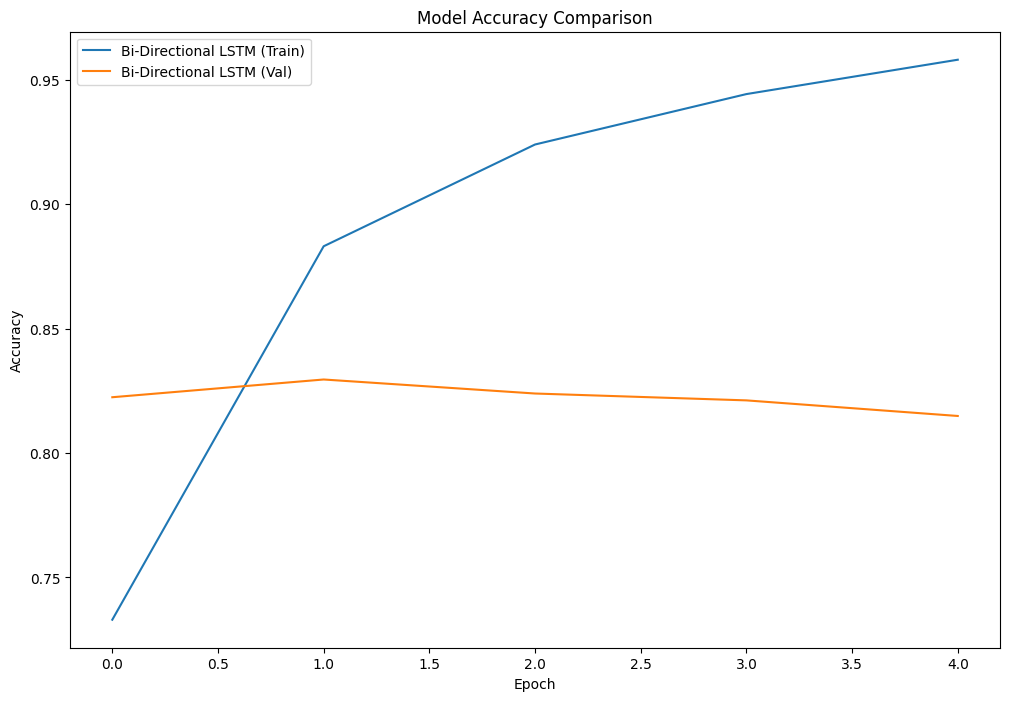

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_bidirectional_lstm(vocab_size, embedding_dim=100, input_length=12, num_classes=8):
    """
    Create a single-layer Bidirectional LSTM model.
    
    Args:
        vocab_size: Size of the vocabulary
        embedding_dim: Dimension of word embeddings
        input_length: Length of input sequences
        num_classes: Number of output classes
    """
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=input_length),
        
        # Bidirectional LSTM layer
        Bidirectional(LSTM(units=128,
                         activation='tanh',
                         recurrent_activation='sigmoid',
                         dropout=0.3,
                         recurrent_dropout=0.2)),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

# Create the Bidirectional LSTM model
vocab_size = embedding_data['vocab_size']
num_classes = len(np.unique(y_train))

bi_lstm = create_bidirectional_lstm(vocab_size, num_classes=num_classes)

# Print model summary
print("\nBidirectional LSTM Architecture:")
bi_lstm.summary()

# Create callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

bi_lstm_checkpoint = ModelCheckpoint(
    'bidirectional_lstm_best.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# Print model summaries
models = {
    'Bi-Directional LSTM': bi_lstm
}

for name, model in models.items():
    print(f"\n{name} Architecture:")
    model.summary()

# Training parameters
train_params = {
    'batch_size': 32,
    'epochs': 20,
    'validation_split': 0.2,
    'callbacks': [early_stopping, bi_lstm_checkpoint]
}

# Dictionary to store training histories
histories = {}

# Train the Bidirectional LSTM model
bi_lstm_history = bi_lstm.fit(
    X_train,
    y_train,
    **train_params
)

histories[name] = bi_lstm_history.history

# Plot training histories
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history['accuracy'], label=f'{name} (Train)')
    plt.plot(history['val_accuracy'], label=f'{name} (Val)')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### **GRU (1 layer)**


Single Layer GRU Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Single Layer GRU...
Epoch 1/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 161s 73ms/step - accuracy: 0.5731 - loss: 1.1554 - val_accuracy: 0.7764 - val_loss: 0.8971
Epoch 2/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 159s 73ms/step - accuracy: 0.8805 - loss: 0.3667 - val_accuracy: 0.7860 - val_loss: 0.8294
Epoch 3/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 156s 72ms/step - accuracy: 0.9267 - loss: 0.2252 - val_accuracy: 0.7815 - val_loss: 0.7507
Epoch 4/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 158s 73ms/step - accuracy: 0.9490 - loss: 0.1523 - val_accuracy: 0.7725 - val_loss: 0.7193
Epoch 5/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 159s 73ms/step - accuracy: 0.9620 - loss: 0.1115 - val_accuracy: 0.7743 - val_loss: 0.6963


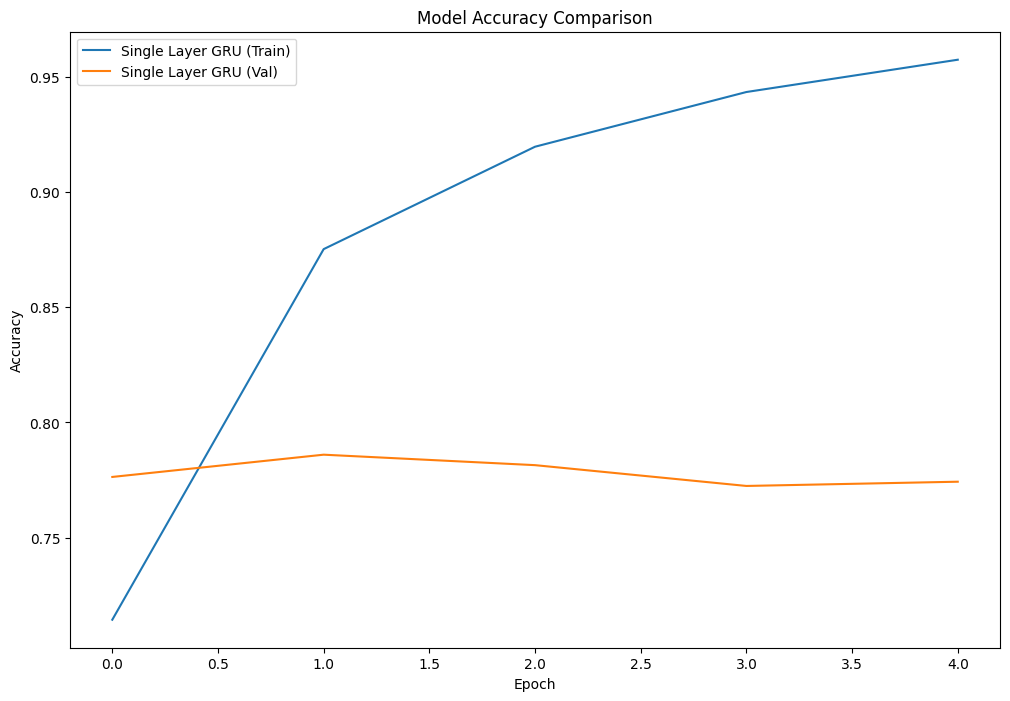

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_single_layer_gru(vocab_size, embedding_dim=100, input_length=12, num_classes=8):
    """
    Create a single-layer GRU model.
    """
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size,
                 output_dim=embedding_dim,
                 input_length=input_length),
        
        # Single GRU layer
        GRU(units=128,
            activation='tanh',
            recurrent_activation='sigmoid',
            dropout=0.3,
            recurrent_dropout=0.2),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    
    return model

# Create callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Create all models
vocab_size = embedding_data['vocab_size']
num_classes = len(np.unique(y_train))

# Initialize models
single_gru = create_single_layer_gru(vocab_size, num_classes=num_classes)

# Print model summaries
models = {
    'Single Layer GRU': single_gru
}

for name, model in models.items():
    print(f"\n{name} Architecture:")
    model.summary()

# Training parameters
train_params = {
    'batch_size': 32,
    'epochs': 20,
    'validation_split': 0.2
}

# Dictionary to store training histories
histories = {}

# Train all models
for name, model in models.items():
    print(f"\nTraining {name}...")
    checkpoint = ModelCheckpoint(
        f'{name.lower().replace(" ", "_")}_best.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        **train_params,
        callbacks=[early_stopping, checkpoint]
    )
    histories[name] = history.history

# Plot training histories
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history['accuracy'], label=f'{name} (Train)')
    plt.plot(history['val_accuracy'], label=f'{name} (Val)')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### **GRU (2 layers)**


Double Layer GRU Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Double Layer GRU...
Epoch 1/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 120s 53ms/step - accuracy: 0.5551 - loss: 1.1969 - val_accuracy: 0.7624 - val_loss: 0.8235
Epoch 2/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 117s 54ms/step - accuracy: 0.8666 - loss: 0.4171 - val_accuracy: 0.7865 - val_loss: 0.6945
Epoch 3/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 140s 53ms/step - accuracy: 0.9145 - loss: 0.2670 - val_accuracy: 0.7866 - val_loss: 0.6522
Epoch 4/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.9379 - loss: 0.1966 - val_accuracy: 0.7776 - val_loss: 0.6646
Epoch 5/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.9518 - loss: 0.1530 - val_accuracy: 0.7715 - val_loss: 0.6821
Epoch 6/20
2176/2176 ━━━━━━━━━━━━━━━━━━━━ 113s 52ms/step - accuracy: 0.9625 - loss: 0.1173 - val_accuracy: 0.7702 - val_loss: 0.6958


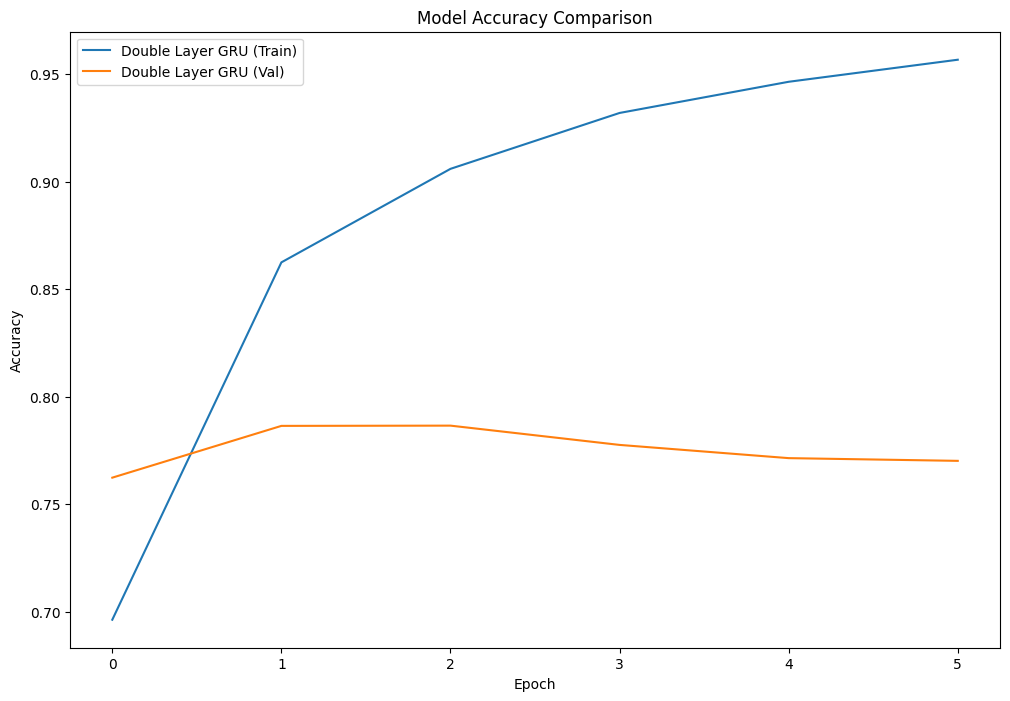

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_Double_layer_gru(vocab_size, embedding_dim=100, input_length=12, num_classes=8):
    """
    Create a Double-layer GRU model.
    """
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size,
                 output_dim=embedding_dim,
                 input_length=input_length),
        
        # First GRU layer
        GRU(units=64,
            activation='tanh',
            recurrent_activation='sigmoid',
            dropout=0.3,
            recurrent_dropout=0.2,
            return_sequences=True),
        
        # Second GRU layer
        GRU(units=32,
            activation='tanh',
            recurrent_activation='sigmoid',
            dropout=0.3,
            recurrent_dropout=0.2),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
    
    return model

# Create callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Create all models
vocab_size = embedding_data['vocab_size']
num_classes = len(np.unique(y_train))

# Initialize models
Double_gru = create_Double_layer_gru(vocab_size, num_classes=num_classes)

# Print model summaries
models = {
    'Double Layer GRU': Double_gru
}

for name, model in models.items():
    print(f"\n{name} Architecture:")
    model.summary()

# Training parameters
train_params = {
    'batch_size': 32,
    'epochs': 20,
    'validation_split': 0.2
}

# Dictionary to store training histories
histories = {}

# Train all models
for name, model in models.items():
    print(f"\nTraining {name}...")
    checkpoint = ModelCheckpoint(
        f'{name.lower().replace(" ", "_")}_best.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        **train_params,
        callbacks=[early_stopping, checkpoint]
    )
    histories[name] = history.history

# Plot training histories
plt.figure(figsize=(12, 8))
for name, history in histories.items():
    plt.plot(history['accuracy'], label=f'{name} (Train)')
    plt.plot(history['val_accuracy'], label=f'{name} (Val)')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## **Model Evaluation**

### **GRU (single layer)**

680/680 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


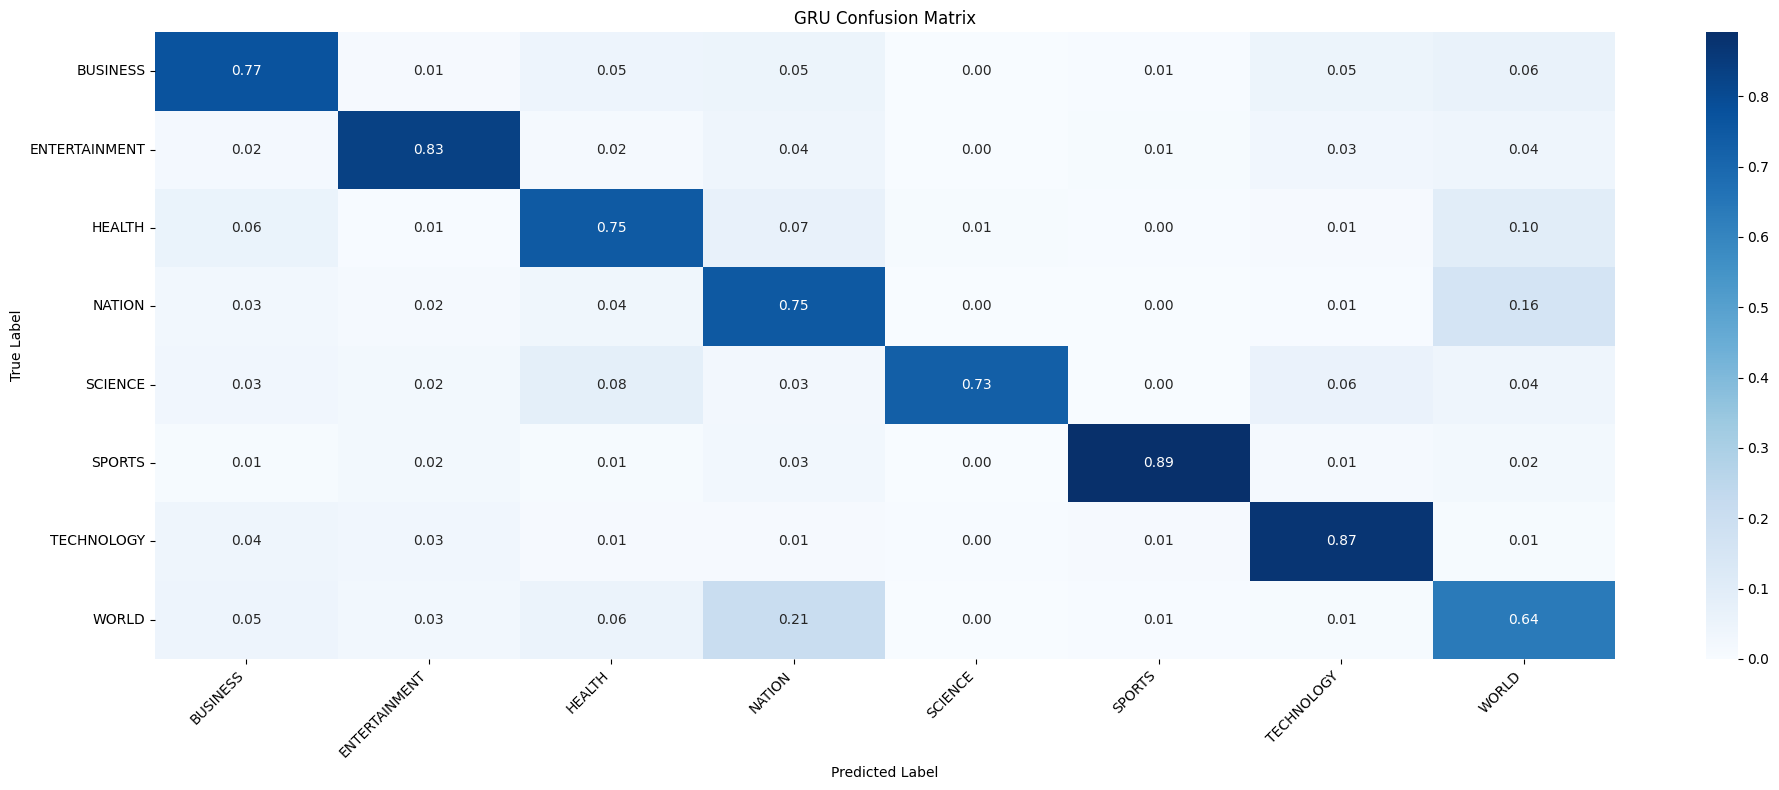

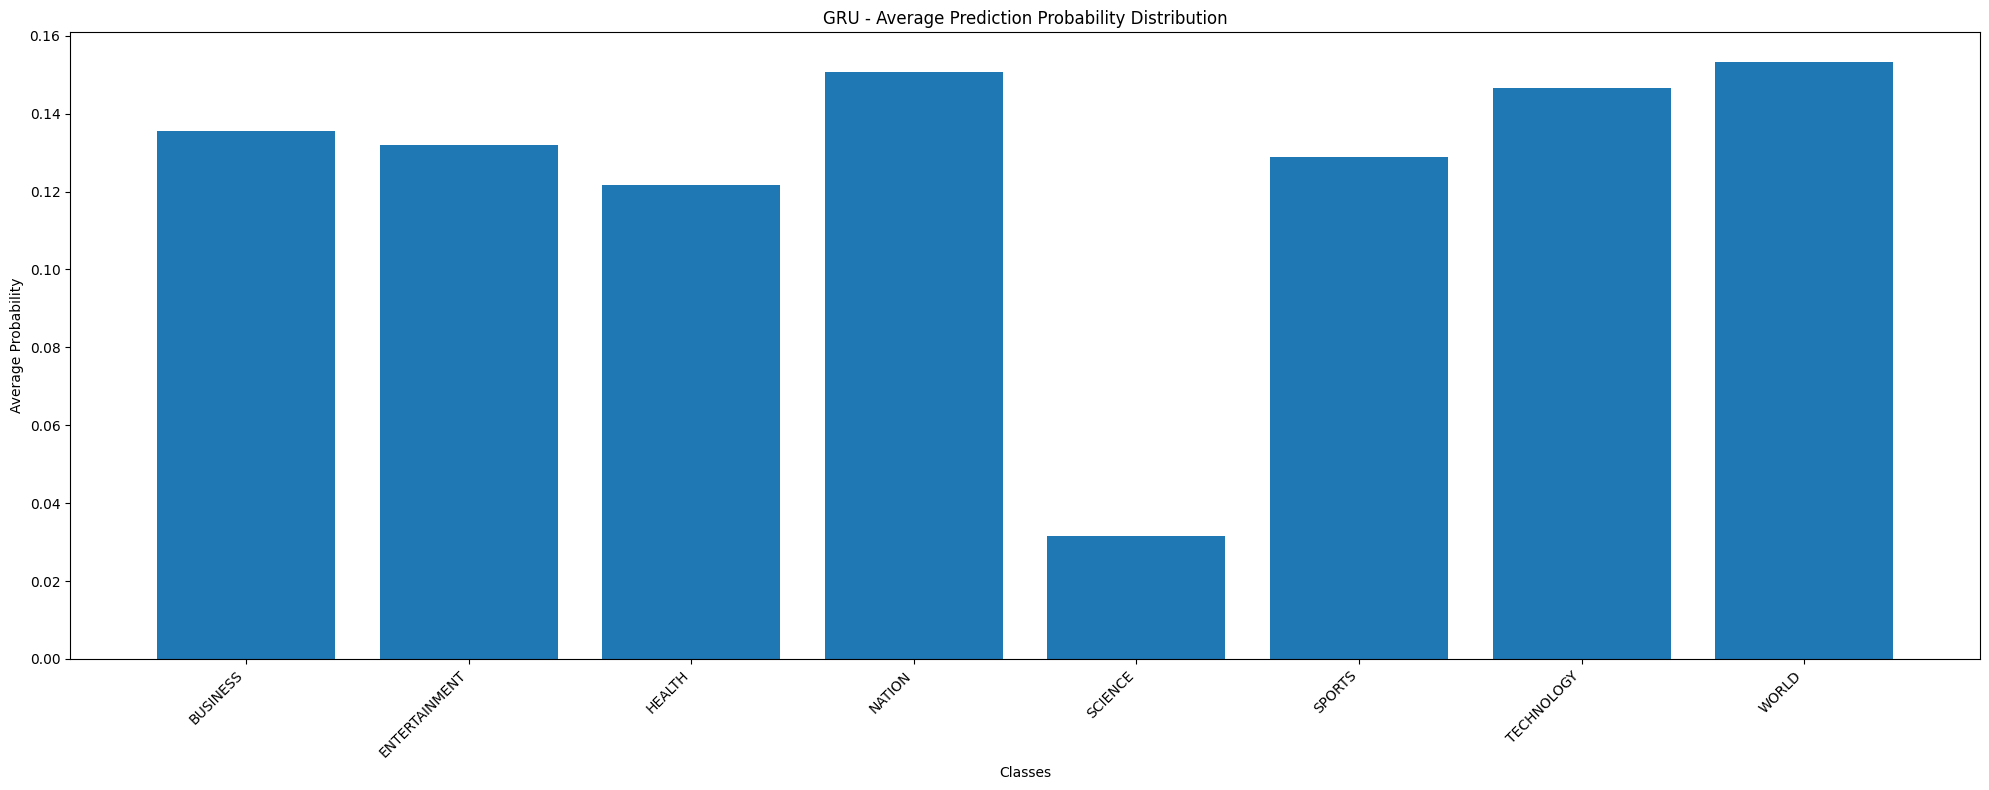


=== Overall Accuracy ===
GRU Accuracy:  0.7841

=== Per-Class Performance Comparison ===

GRU Metrics:
       Class   Precision      Recall    F1-Score
    BUSINESS       0.782       0.771       0.777
ENTERTAINMENT       0.868       0.834       0.851
      HEALTH       0.790       0.747       0.768
      NATION       0.639       0.749       0.690
     SCIENCE       0.906       0.730       0.809
      SPORTS       0.959       0.891       0.924
  TECHNOLOGY       0.863       0.871       0.867
       WORLD       0.611       0.640       0.625

=== Aggregate Metrics Comparison ===

macro avg:
                    GRU 
precision         0.802
recall            0.779
f1-score          0.789

weighted avg:
                    GRU 
precision         0.792
recall            0.784
f1-score          0.787


In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def gru_model_eval(gru_model, X_test, y_test, class_names):

    # Get predictions from both models
    gru_pred_probs = gru_model.predict(X_test)
    
    gru_pred = np.argmax(gru_pred_probs, axis=1)
    
    # Calculate metrics for both models
    metrics = {
        'GRU': {
            'accuracy': accuracy_score(y_test, gru_pred),
            'report': classification_report(y_test, gru_pred, 
                                         target_names=class_names, 
                                         output_dict=True),
            'cm': confusion_matrix(y_test, gru_pred),
            'pred_probs': gru_pred_probs
        }
    }
    
    # Plot confusion matrices side by side
    fig, ax1 = plt.subplots(1, figsize=(20, 8))
    
    # GRU confusion matrix
    cm_gru_norm = metrics['GRU']['cm'].astype('float') / metrics['GRU']['cm'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_gru_norm, annot=True, fmt='.2f', 
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', ax=ax1)
    ax1.set_title('GRU Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Plot prediction probability distributions
    fig, ax1 = plt.subplots(1, figsize=(20, 8))
    
    # GRU probabilities
    avg_probs_gru = np.mean(metrics['GRU']['pred_probs'], axis=0)
    ax1.bar(class_names, avg_probs_gru)
    ax1.set_title('GRU - Average Prediction Probability Distribution')
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Average Probability')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

def display_comparative_metrics(metrics):

    # Print overall accuracy comparison
    print("\n=== Overall Accuracy ===")
    print(f"GRU Accuracy:  {metrics['GRU']['accuracy']:.4f}")
    
    # Print per-class metrics comparison
    print("\n=== Per-Class Performance Comparison ===")
    headers = ['Precision', 'Recall', 'F1-Score']
    row_format = "{:>12}" * (len(headers) + 1)
    
    for model_name in ['GRU']:
        print(f"\n{model_name} Metrics:")
        print(row_format.format("Class", *headers))
        
        report = metrics[model_name]['report']
        for class_name in report.keys():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                m = report[class_name]
                print(row_format.format(
                    class_name,
                    f"{m['precision']:.3f}",
                    f"{m['recall']:.3f}",
                    f"{m['f1-score']:.3f}"
                ))
    
    # Print aggregate metrics comparison
    print("\n=== Aggregate Metrics Comparison ===")
    for avg_type in ['macro avg', 'weighted avg']:
        print(f"\n{avg_type}:")
        gru_metrics = metrics['GRU']['report'][avg_type]
        
        print(f"{'':12} {'GRU':>10} ")
        for metric in ['precision', 'recall', 'f1-score']:
            gru_value = gru_metrics[metric]
            print(f"{metric:12} {gru_value:10.3f}")


# Get class names from label encoder
class_names = embedding_data['label_encoder'].classes_

# Compare models
comparison_metrics = gru_model_eval(
    Double_gru,
    X_test,
    y_test,
    class_names
)

# Display detailed metrics
display_comparative_metrics(comparison_metrics)


### **GRU (Double layer)**

680/680 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


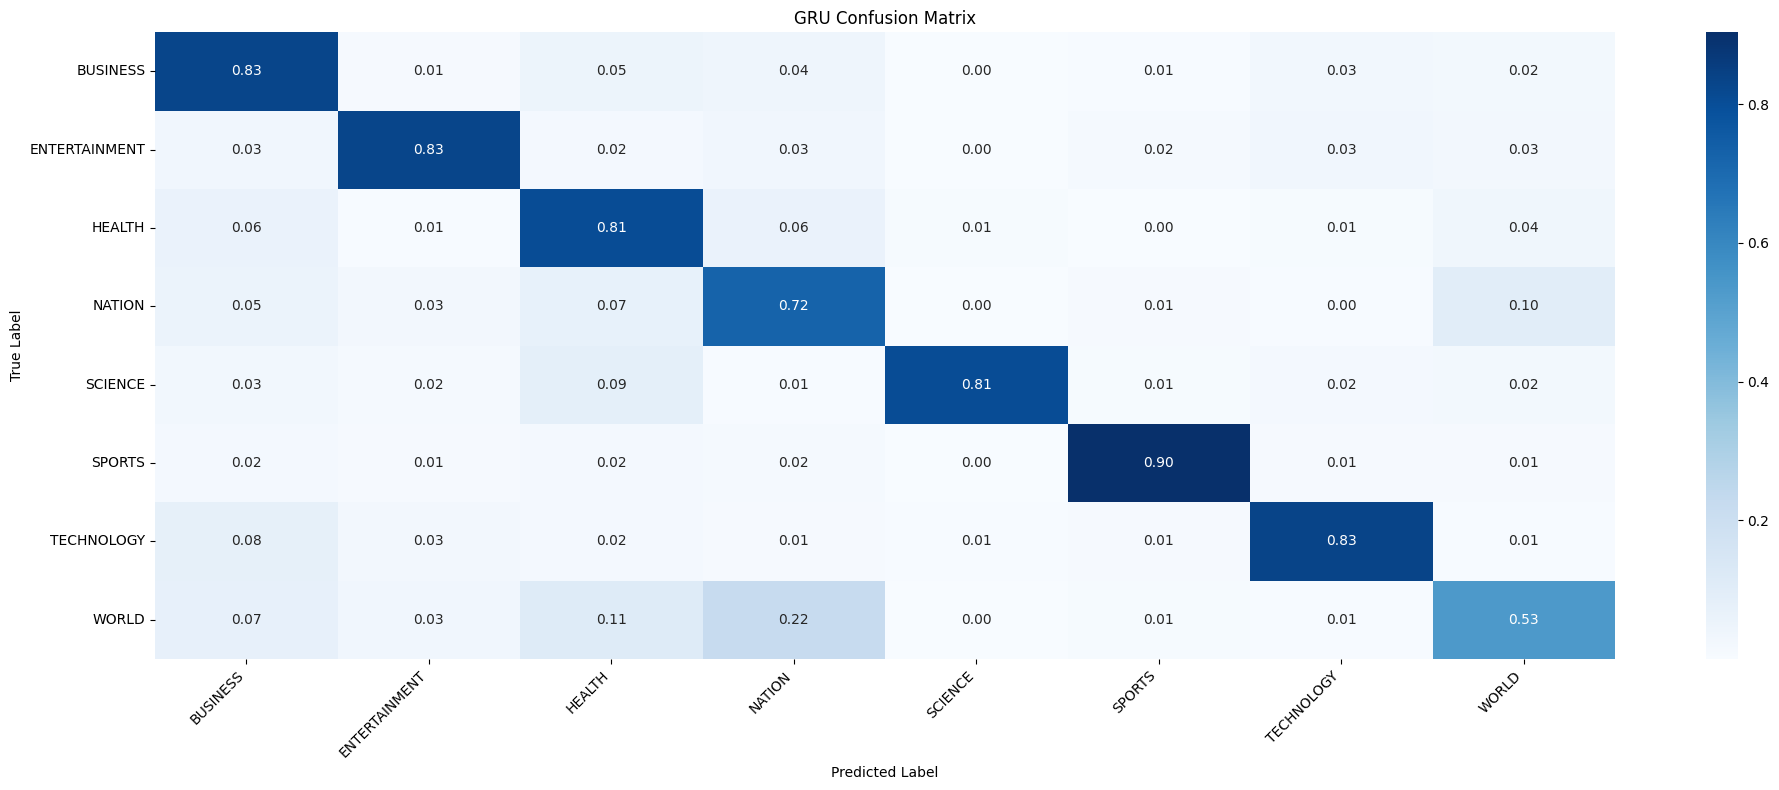

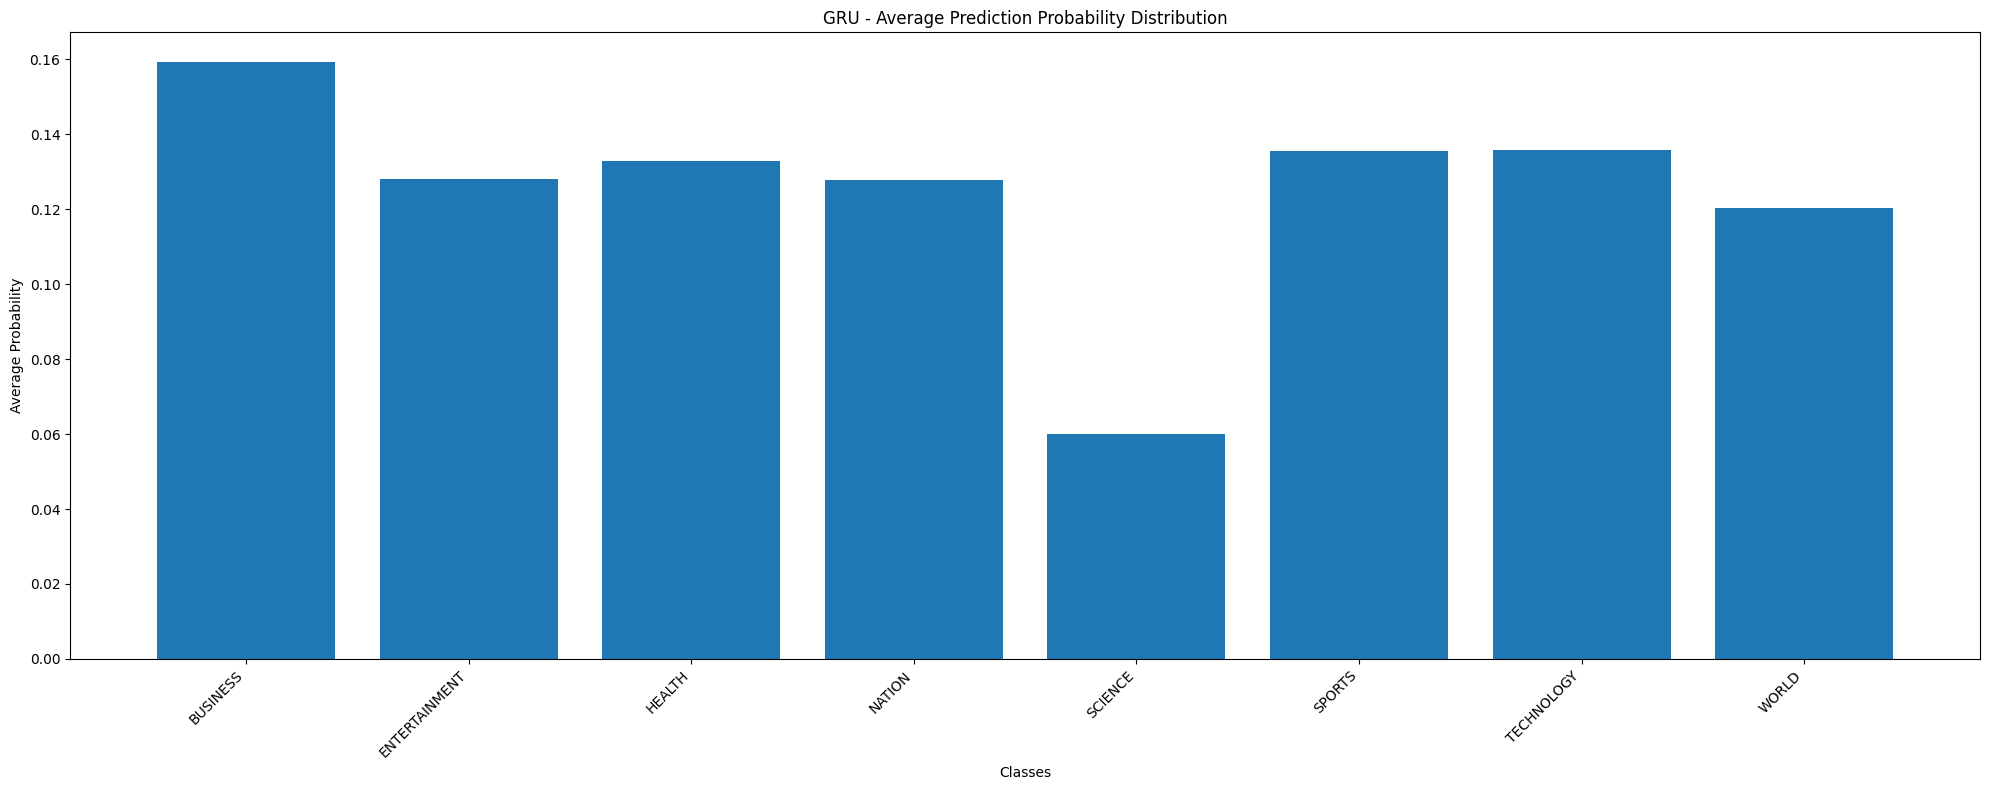


=== Overall Accuracy ===
GRU Accuracy:  0.7821

=== Per-Class Performance Comparison ===

GRU Metrics:
       Class   Precision      Recall    F1-Score
    BUSINESS       0.713       0.832       0.768
ENTERTAINMENT       0.869       0.832       0.850
      HEALTH       0.717       0.808       0.760
      NATION       0.649       0.724       0.685
     SCIENCE       0.883       0.807       0.843
      SPORTS       0.936       0.904       0.919
  TECHNOLOGY       0.889       0.835       0.861
       WORLD       0.712       0.534       0.610

=== Aggregate Metrics Comparison ===

macro avg:
                    GRU 
precision         0.796
recall            0.784
f1-score          0.787

weighted avg:
                    GRU 
precision         0.787
recall            0.782
f1-score          0.781


In [24]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def gru_model_eval(gru_model, X_test, y_test, class_names):

    # Get predictions from both models
    gru_pred_probs = gru_model.predict(X_test)
    
    gru_pred = np.argmax(gru_pred_probs, axis=1)
    
    # Calculate metrics for both models
    metrics = {
        'GRU': {
            'accuracy': accuracy_score(y_test, gru_pred),
            'report': classification_report(y_test, gru_pred, 
                                         target_names=class_names, 
                                         output_dict=True),
            'cm': confusion_matrix(y_test, gru_pred),
            'pred_probs': gru_pred_probs
        }
    }
    
    # Plot confusion matrices side by side
    fig, ax1 = plt.subplots(1, figsize=(20, 8))
    
    # GRU confusion matrix
    cm_gru_norm = metrics['GRU']['cm'].astype('float') / metrics['GRU']['cm'].sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_gru_norm, annot=True, fmt='.2f', 
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', ax=ax1)
    ax1.set_title('GRU Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Plot prediction probability distributions
    fig, ax1 = plt.subplots(1, figsize=(20, 8))
    
    # GRU probabilities
    avg_probs_gru = np.mean(metrics['GRU']['pred_probs'], axis=0)
    ax1.bar(class_names, avg_probs_gru)
    ax1.set_title('GRU - Average Prediction Probability Distribution')
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Average Probability')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

def display_comparative_metrics(metrics):

    # Print overall accuracy comparison
    print("\n=== Overall Accuracy ===")
    print(f"GRU Accuracy:  {metrics['GRU']['accuracy']:.4f}")
    
    # Print per-class metrics comparison
    print("\n=== Per-Class Performance Comparison ===")
    headers = ['Precision', 'Recall', 'F1-Score']
    row_format = "{:>12}" * (len(headers) + 1)
    
    for model_name in ['GRU']:
        print(f"\n{model_name} Metrics:")
        print(row_format.format("Class", *headers))
        
        report = metrics[model_name]['report']
        for class_name in report.keys():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                m = report[class_name]
                print(row_format.format(
                    class_name,
                    f"{m['precision']:.3f}",
                    f"{m['recall']:.3f}",
                    f"{m['f1-score']:.3f}"
                ))
    
    # Print aggregate metrics comparison
    print("\n=== Aggregate Metrics Comparison ===")
    for avg_type in ['macro avg', 'weighted avg']:
        print(f"\n{avg_type}:")
        gru_metrics = metrics['GRU']['report'][avg_type]
        
        print(f"{'':12} {'GRU':>10} ")
        for metric in ['precision', 'recall', 'f1-score']:
            gru_value = gru_metrics[metric]
            print(f"{metric:12} {gru_value:10.3f}")


# Get class names from label encoder
class_names = embedding_data['label_encoder'].classes_

# Compare models
comparison_metrics = gru_model_eval(
    single_gru,
    X_test,
    y_test,
    class_names
)

# Display detailed metrics
display_comparative_metrics(comparison_metrics)


### **Bi-Dir LSTM (single layer)**

680/680 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step

=== Evaluation Metrics for Bidirectional LSTM ===

Overall Accuracy: 0.8290

Per-Class Metrics:
       Class   Precision      Recall    F1-Score     Support
    BUSINESS       0.851       0.790       0.819        3000
ENTERTAINMENT       0.859       0.914       0.885        3000
      HEALTH       0.766       0.870       0.815        3000
      NATION       0.713       0.754       0.733        3000
     SCIENCE       0.920       0.825       0.870         755
      SPORTS       0.965       0.928       0.946        3000
  TECHNOLOGY       0.902       0.900       0.901        3000
       WORLD       0.734       0.649       0.689        3000

Aggregate Metrics:
macro avg:
  Precision: 0.839
  Recall: 0.829
  F1-Score: 0.832
weighted avg:
  Precision: 0.831
  Recall: 0.829
  F1-Score: 0.828


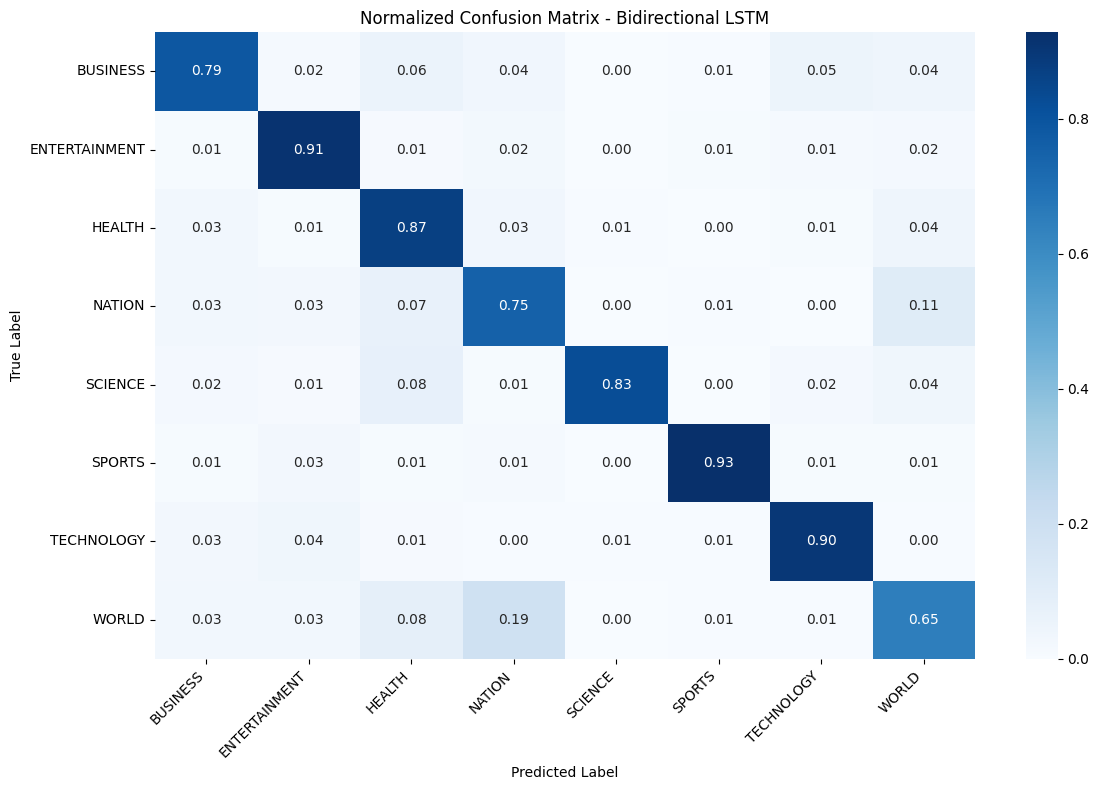

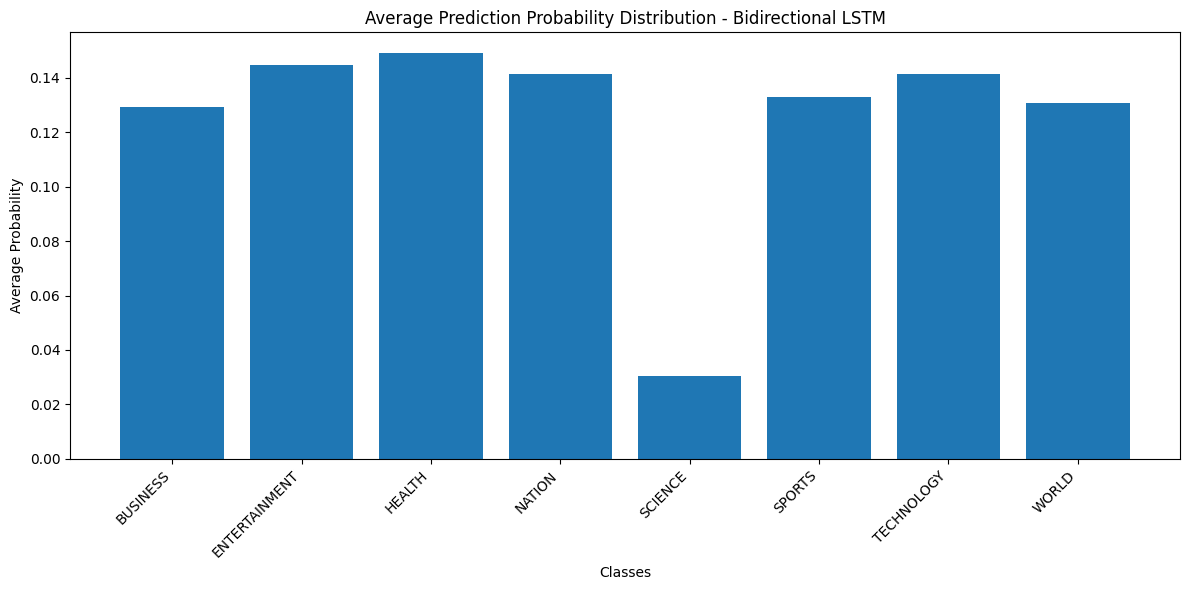

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def evaluate_bidirectional_lstm(model, X_test, y_test, class_names):
    """
    Evaluate the performance of a Bidirectional LSTM model.
    
    Args:
        model: Trained Bidirectional LSTM model
        X_test: Test features
        y_test: True labels
        class_names: Names of the classes
    
    Returns:
        dict: Dictionary containing all evaluation metrics
    """
    # Get predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Get detailed classification report
    report = classification_report(y_test, y_pred, 
                                 target_names=class_names, 
                                 output_dict=True)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create confusion matrix plot
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm_normalized, 
                annot=True, 
                fmt='.2f', 
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title('Normalized Confusion Matrix - Bidirectional LSTM')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Store results
    evaluation_results = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'confusion_matrix_normalized': cm_normalized,
        'predictions': y_pred,
        'prediction_probabilities': y_pred_probs
    }
    
    return evaluation_results

def plot_bidirectional_lstm_prediction_distribution(y_pred_probs, class_names):
    """
    Plot distribution of prediction probabilities for the Bidirectional LSTM model.
    
    Args:
        y_pred_probs: Prediction probabilities from the Bidirectional LSTM model
        class_names: Names of the classes
    """
    plt.figure(figsize=(12, 6))
    
    # Calculate average prediction probability for each class
    avg_probs = np.mean(y_pred_probs, axis=0)
    
    # Create bar plot
    plt.bar(class_names, avg_probs)
    plt.title('Average Prediction Probability Distribution - Bidirectional LSTM')
    plt.xlabel('Classes')
    plt.ylabel('Average Probability')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

def display_bidirectional_lstm_evaluation_metrics(eval_results):
    """
    Display all evaluation metrics for the Bidirectional LSTM model in a formatted way.
    
    Args:
        eval_results: Dictionary containing evaluation metrics
    """
    print("\n=== Evaluation Metrics for Bidirectional LSTM ===")
    print(f"\nOverall Accuracy: {eval_results['accuracy']:.4f}")
    
    # Display classification report metrics
    report = eval_results['classification_report']
    
    print("\nPer-Class Metrics:")
    headers = ['Precision', 'Recall', 'F1-Score', 'Support']
    row_format = "{:>12}" * (len(headers) + 1)
    print(row_format.format("Class", *headers))
    
    for class_name in report.keys():
        if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
            metrics = report[class_name]
            print(row_format.format(
                class_name,
                f"{metrics['precision']:.3f}",
                f"{metrics['recall']:.3f}",
                f"{metrics['f1-score']:.3f}",
                f"{metrics['support']}"
            ))
    
    print("\nAggregate Metrics:")
    for avg_type in ['macro avg', 'weighted avg']:
        metrics = report[avg_type]
        print(f"{avg_type}:")
        print(f"  Precision: {metrics['precision']:.3f}")
        print(f"  Recall: {metrics['recall']:.3f}")
        print(f"  F1-Score: {metrics['f1-score']:.3f}")

# Load the trained Bidirectional LSTM model
bi_lstm = load_model('bidirectional_lstm_best.keras')

# Get class names
class_names = embedding_data['label_encoder'].classes_

# Evaluate the Bidirectional LSTM model
bi_lstm_eval = evaluate_bidirectional_lstm(bi_lstm, X_test, y_test, class_names)

# Display evaluation metrics
display_bidirectional_lstm_evaluation_metrics(bi_lstm_eval)

# Plot prediction probability distribution
plot_bidirectional_lstm_prediction_distribution(
    bi_lstm_eval['prediction_probabilities'],
    class_names
)
plt.show()

|RNN|LSTM|GRU|Bi-Dir LSTMs|
|---|---|---|---|
| 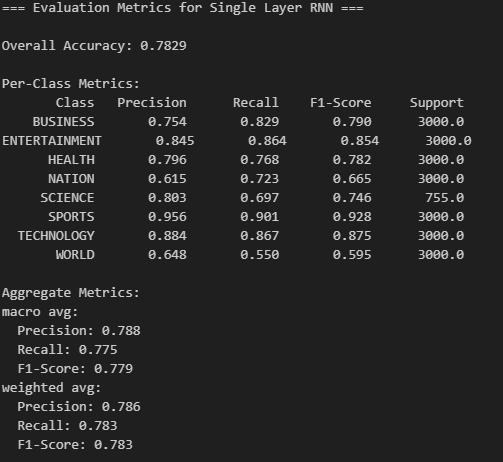|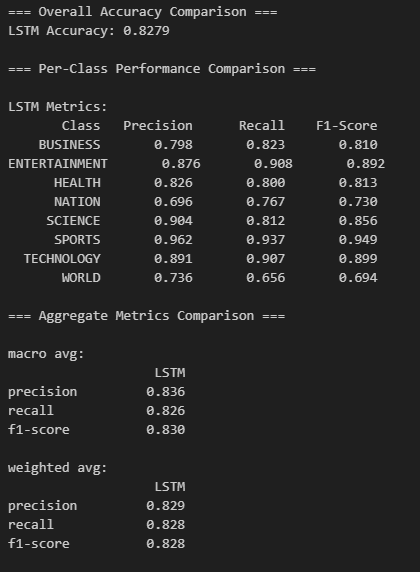| 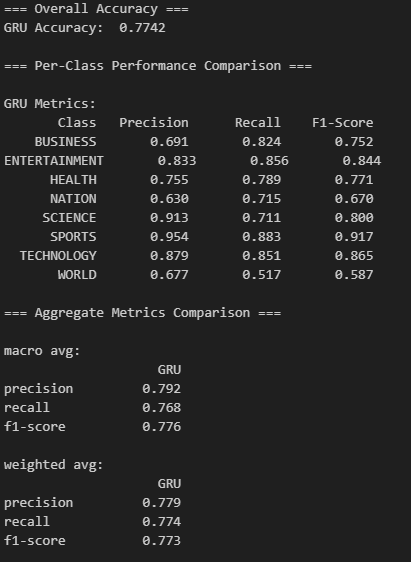 |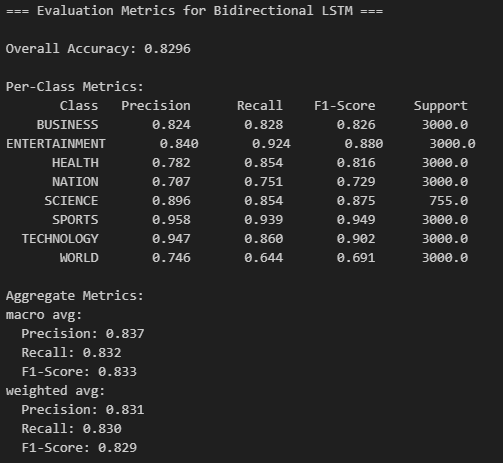|

### **Comments** (Reboot)
For the Midterm assignment, The setup is completely uniform. I have not made a single change in how the data is processed and inserted into the RNN, LSTM or GRUs. As we can see, overall the GRU model has underperformed both the RNN and LSTM. Although it outperforms the RNN model on a few metrics by a small margin, it is still quite inferior to the performance provided by the LSTMs.

According to my knowledge and observations, a few reasons as to why this might be occurring are:

1. GRUs are a simpler model compared to LSTMs (2 gates instead of LSTM's 3 gates), and thus GRUs are faster and less complex to train, which comes at the cost of performance.
2. GRUs lack an internal memory cell, due to its lighter architecture. this leads to lower learning capacities, long term dependency issues, and worse at preserving context over longer sequences.
3. Although LSTMs are more prone to overfitting, they are still better in terms of performance. This results in LSTMs outperforming GRUs more often than not.